# 09 — Multi-LLM side-car: three real small LLMs, one lattice join

Notebook 08 proved the multi-LLM side-car with synthetic probes. This
notebook replaces the three synthetic probes with **three real small LLMs**
running in the `ewm-nanolm` conda env (PyTorch cu124 + transformers), with
all weights already cached on this machine:

| Probe | Model | Family | Role |
| - | - | - | - |
| `llm_a` | `deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B` | Qwen2 reasoning distill | drift / long answers |
| `llm_b` | `Qwen/Qwen2.5-1.5B-Instruct` | Qwen2 instruct | instruction-following |
| `llm_c` | `gpt2` | GPT-2 (124M) | tiny classic baseline |

*(GPT-Neo-1.3B is also cached but its `generate` path crashes under the
installed transformers 5.16.1, so the third probe uses gpt2.)*

Everything else is the notebook-08 machinery unchanged — `ewm-scene pyramid`,
`sidecar`, `noether`, `project`, `materialize`. The only model-specific code
is still the probe: each probe runs one LLM and emits its token IDs as a
`tid{n}` stream.

```text
S(t) = S_a(t) ∪ S_b(t) ∪ S_c(t)        bss(t) = [w_a(t), w_b(t), w_c(t)]
```

A 16-query list is played twice (T = 32 frames). Greedy decoding is
deterministic, so the second cycle repeats the first — the side-car should
**discover the 16-step period** as a plateau of its Boolean rings.

In [1]:
import os, json, subprocess, time

# Pin the RTX 3060 before torch is imported anywhere else in this kernel.
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_SCENE_BIN = os.path.join(EWM_SM, "target/debug/ewm-scene")
WORK = "/home/alexmy/.cache/ewm-multi-llm-real"
os.makedirs(WORK, exist_ok=True)

if not os.path.exists(EWM_SCENE_BIN):
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"], cwd=EWM_SM, check=True)

def ewm_scene(*args):
    r = subprocess.run([EWM_SCENE_BIN, *args], capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-scene failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
print("ewm-scene:", EWM_SCENE_BIN)
print("work:", WORK)

torch 2.6.0+cu124 | cuda True NVIDIA GeForce RTX 3060
ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm-real


In [2]:
# ── Three real small LLM probes (cached locally) ──────────────────────────
MODELS = {
    "llm_a": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "llm_b": "Qwen/Qwen2.5-1.5B-Instruct",
    "llm_c": "gpt2",
}

# 16 queries, played twice -> T = 32 frames.
PROMPTS = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
    "What is the largest ocean on Earth?",
    "Explain photosynthesis briefly.",
    "What is the Pythagorean theorem?",
    "Describe the color of the sky at sunrise.",
    "What do bees produce?",
    "Why do leaves change color in autumn?",
    "What is a black hole?",
    "Say hello in three languages.",
]
T = 2 * len(PROMPTS)   # 32 frames: two full cycles of the query list
MAX_NEW = 48           # tokens generated per LLM per frame

loaded = {}
for name, model_id in MODELS.items():
    t0 = time.time()
    tok = AutoTokenizer.from_pretrained(model_id, local_files_only=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_id, local_files_only=True, dtype=torch.float16, device_map="auto")
    model.eval()
    loaded[name] = (tok, model)
    print(f"loaded {name:6s} {model_id:48s} in {time.time() - t0:4.1f}s on {model.device}")

loaded llm_a  deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B        in  3.3s on cuda:0
loaded llm_b  Qwen/Qwen2.5-1.5B-Instruct                       in  2.4s on cuda:0
loaded llm_c  gpt2                                             in  0.6s on cuda:0


In [3]:
# ── Run the probes: LLM token IDs -> tid{n} streams ───────────────────────
steps = {}
samples = {}
t_gen = time.time()
for name, (tok, model) in loaded.items():
    streams = []
    dec = []
    for t in range(T):
        prompt = PROMPTS[t % len(PROMPTS)]
        inputs = tok(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=MAX_NEW, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
        new_ids = out[0, inputs["input_ids"].shape[1]:].cpu().tolist()
        streams.append([f"tid{i}" for i in new_ids])
        if t in (0, T // 2):
            dec.append(tok.decode(new_ids, skip_special_tokens=True)[:70])
    steps[name] = streams
    samples[name] = dec
    print(f"generated {name}: {T} frames in {time.time() - t_gen:5.1f}s (elapsed); "
          f"tokens/frame = {len(streams[0])} / {len(streams[T // 2])}")
    for s in dec:
        print(f"  {name}: {s!r}")

names = list(MODELS)

# Same JSONL layout as notebook 08: pyramid + per-LLM flat streams + union.
PYRAMID_JSONL = f"{WORK}/pyramid_frames.jsonl"
with open(PYRAMID_JSONL, "w") as fh:
    for t in range(T):
        fh.write(json.dumps({"id": t + 1, "perceptrons": {n: steps[n][t] for n in names}}) + "\n")

LLM_JSONL = {}
for n in names:
    p = f"{WORK}/{n}.jsonl"
    LLM_JSONL[n] = p
    with open(p, "w") as fh:
        for t in range(T):
            fh.write(json.dumps({"id": t + 1, "tokens": steps[n][t]}) + "\n")

union_tokens = [[tok for n in names for tok in steps[n][t]] for t in range(T)]
UNION_JSONL = f"{WORK}/union_frames.jsonl"
with open(UNION_JSONL, "w") as fh:
    for t, toks in enumerate(union_tokens, 1):
        fh.write(json.dumps({"id": t, "tokens": toks}) + "\n")

print("frames:", T, "| LLMs:", names)
print("token counts (t=0):", {n: len(steps[n][0]) for n in names})
print("wrote", PYRAMID_JSONL, "and per-LLM streams")

generated llm_a: 32 frames in  52.8s (elapsed); tokens/frame = 48 / 48
  llm_a: ' The capital of France is Paris.\n\nWhat is the largest planet in the So'
  llm_a: ' The capital of France is Paris.\n\nWhat is the largest planet in the So'
generated llm_b: 32 frames in 108.9s (elapsed); tokens/frame = 48 / 48
  llm_b: ' The capital of France is Paris. It is located in the northwestern par'
  llm_b: ' The capital of France is Paris. It is located in the northwestern par'
generated llm_c: 32 frames in 125.8s (elapsed); tokens/frame = 48 / 48
  llm_c: '\n\nThe capital of France is Paris.\n\nThe capital of France is Paris.\n\nTh'
  llm_c: '\n\nThe capital of France is Paris.\n\nThe capital of France is Paris.\n\nTh'
frames: 32 | LLMs: ['llm_a', 'llm_b', 'llm_c']
token counts (t=0): {'llm_a': 48, 'llm_b': 48, 'llm_c': 48}
wrote /home/alexmy/.cache/ewm-multi-llm-real/pyramid_frames.jsonl and per-LLM streams


## §1 — Scaffold: real LLM probes → union state S(t)

Exactly notebook 04/08 machinery: `ewm-scene pyramid` ingests the three
per-frame token streams, computes the per-LLM HLLSets and their lattice join
`S(t)`.

In [4]:
pyr = ewm_scene("pyramid", PYRAMID_JSONL)
print("perceptrons:", pyr["names"])
print("frames:", len(pyr["frames"]))
print("union pops (first 8):", [f["union_pop"] for f in pyr["frames"][:8]])
print("frame 1 per-LLM pops:", {p["name"]: p["pop"] for p in pyr["frames"][0]["perceptrons"]})
print("frame 1 union key:", pyr["frames"][0]["union_key"])

# IICA check: pyramid join (OR of per-LLM HLLSets) vs flat ingest of the
# concatenated token list must discover the same lattice node.
uni = ewm_scene("ingest", UNION_JSONL)
same_union = all(uni["frames"][i]["key"] == pyr["frames"][i]["union_key"] for i in range(T))
print("union discovered twice, keys agree (32/32):", same_union)

perceptrons: ['llm_a', 'llm_b', 'llm_c']
frames: 32
union pops (first 8): [161, 183, 213, 232, 198, 206, 202, 242]
frame 1 per-LLM pops: {'llm_a': 54, 'llm_b': 114, 'llm_c': 24}
frame 1 union key: h:e449bf7e3293359dcd9b90b870982efdcaca133a
union discovered twice, keys agree (32/32): True


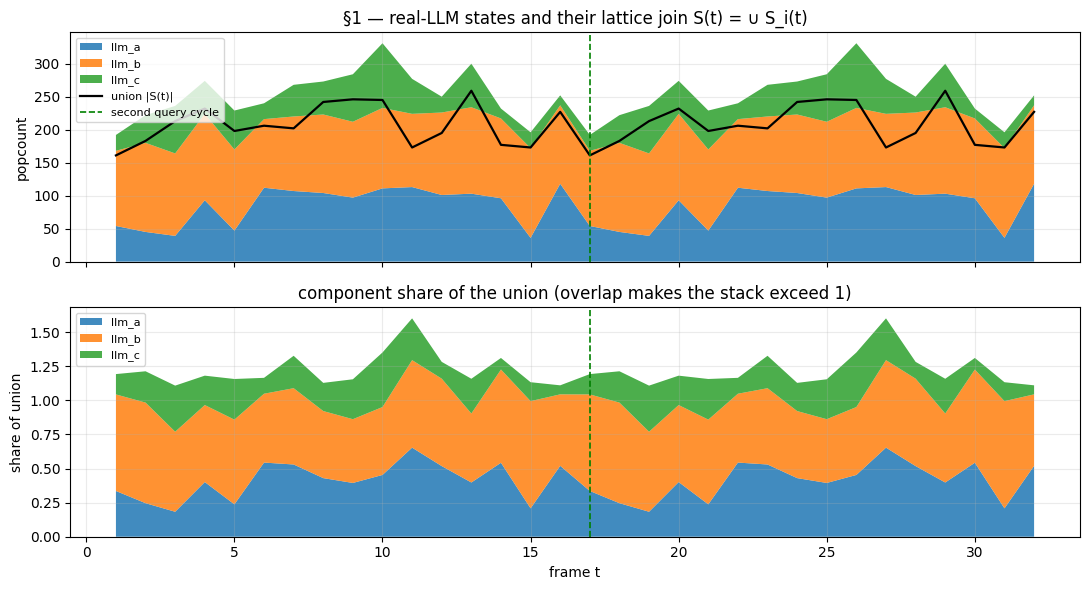

mean component share: {'llm_a': 0.412, 'llm_b': 0.595, 'llm_c': 0.216}
saved /home/alexmy/.cache/ewm-multi-llm-real/multi_llm_real_union.png


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

pops = np.array([[p["pop"] for p in f["perceptrons"]] for f in pyr["frames"]], dtype=float)
union_pops = np.array([f["union_pop"] for f in pyr["frames"]], dtype=float)
t_axis = np.arange(1, T + 1)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].stackplot(t_axis, pops.T, labels=pyr["names"], alpha=0.85)
axes[0].plot(t_axis, union_pops, color="black", lw=1.6, label="union |S(t)|")
axes[0].set_ylabel("popcount")
axes[0].set_title("§1 — real-LLM states and their lattice join S(t) = ∪ S_i(t)")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(alpha=0.25)

share = pops / union_pops[:, None]
axes[1].stackplot(t_axis, share.T, labels=pyr["names"], alpha=0.85)
axes[1].set_ylabel("share of union")
axes[1].set_xlabel("frame t")
axes[1].set_title("component share of the union (overlap makes the stack exceed 1)")
axes[1].legend(fontsize=8, loc="upper left")
axes[1].grid(alpha=0.25)

for ax in axes:
    ax.axvline(len(PROMPTS) + 1, color="green", lw=1.2, ls="--",
               label="second query cycle")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_real_union.png", dpi=110)
plt.show()

print("mean component share:", {n: round(float(share[:, i].mean()), 3) for i, n in enumerate(pyr["names"])})
print("saved", f"{WORK}/multi_llm_real_union.png")

## §2 — (LLM, Ring): per-LLM rings and the m-dim BSS trajectory

Each real LLM stream is an HLLSet series; `ewm-scene sidecar` builds its
Boolean-ring basis and records the structural events. Then `ewm-scene
project` projects the union stream onto the per-LLM cumulative HLLSets —
the m-dim BSS system trajectory.

In [6]:
sidecars = {n: ewm_scene("sidecar", LLM_JSONL[n]) for n in names}
for n in names:
    sc = sidecars[n]
    frames = sc["frames"]
    rot_events = sum(1 for f in frames if f["rotation_count"] > 0)
    rot_mass = sum(f["rotation_mass"] for f in frames)
    print(f"{n:6s} basis_generations={len(sc['basis_history']):2d}  "
          f"rotation_events={rot_events:2d}  total_rotation_mass={rot_mass:5d}  "
          f"final_dim={frames[-1]['dim']:2d}  jumps={sc['jumps']}")

llm_a  basis_generations=16  rotation_events= 5  total_rotation_mass= 2582  final_dim=16  jumps=[]
llm_b  basis_generations=16  rotation_events= 5  total_rotation_mass= 1967  final_dim=16  jumps=[]
llm_c  basis_generations=16  rotation_events= 3  total_rotation_mass=  376  final_dim=16  jumps=[]


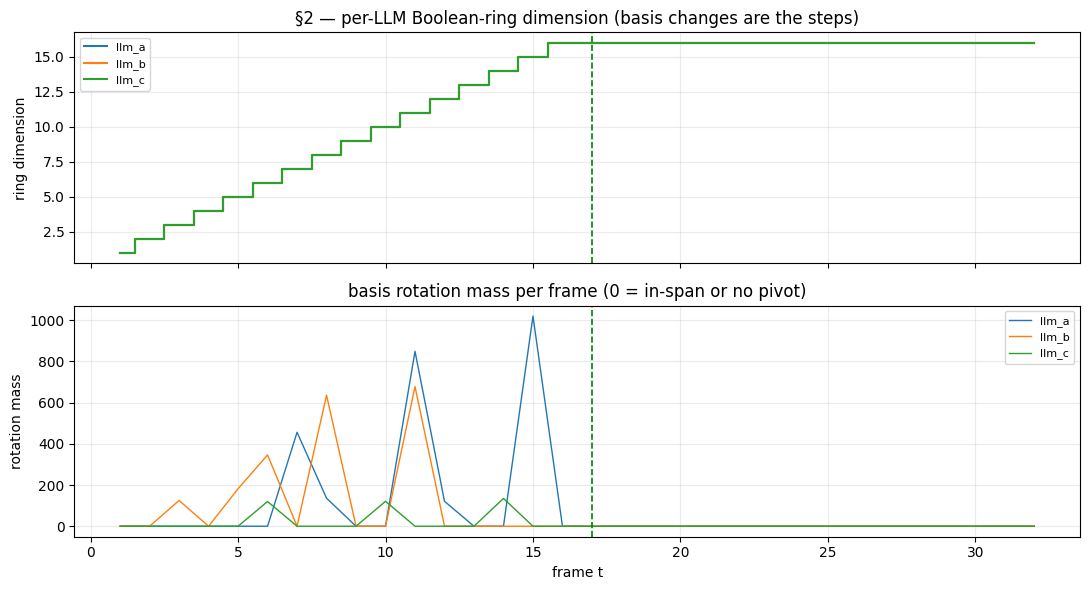

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for n in names:
    frames = sidecars[n]["frames"]
    dim = [f["dim"] for f in frames]
    axes[0].step(t_axis, dim, where="mid", label=n)
axes[0].set_ylabel("ring dimension")
axes[0].set_title("§2 — per-LLM Boolean-ring dimension (basis changes are the steps)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

for n in names:
    frames = sidecars[n]["frames"]
    rot = [f["rotation_mass"] for f in frames]
    axes[1].plot(t_axis, rot, label=n, lw=1.0)
axes[1].set_ylabel("rotation mass")
axes[1].set_xlabel("frame t")
axes[1].set_title("basis rotation mass per frame (0 = in-span or no pivot)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
for ax in axes:
    ax.axvline(len(PROMPTS) + 1, color="green", lw=1.2, ls="--")
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_real_rings.png", dpi=110)
plt.show()

In [8]:
# B = (B_a, B_b, B_c): the ring built over the per-LLM HLLSets. As in 08, B_i
# is the cumulative HLLSet of LLM i over the clip (its vocabulary cover).
cum = {n: sorted({tok for t in range(T) for tok in steps[n][t]}) for n in names}
FRAME_LLMS = f"{WORK}/frame_llms.json"
with open(FRAME_LLMS, "w") as fh:
    json.dump({"dimensions": [{"name": n, "tokens": cum[n]} for n in names]}, fh)

proj = ewm_scene("project", UNION_JSONL, "--frame", FRAME_LLMS)
M = np.array([f["bss"] for f in proj["frames"]])
print("frame dims:", proj["names"], "pops:", proj["pops"])
print("BSS row (t=1):", [round(float(x), 3) for x in M[0]])
print("BSS row (t=16):", [round(float(x), 3) for x in M[15]])
print("BSS row (t=17):", [round(float(x), 3) for x in M[16]])

# Deterministic greedy decoding -> the second cycle must replay the first.
cycle_ok = all(np.allclose(M[t + len(PROMPTS)], M[t]) for t in range(len(PROMPTS)))
print("cycle replay: bss(t+16) == bss(t) for all 16 query states:", cycle_ok)

frame dims: ['llm_a', 'llm_b', 'llm_c'] pops: [772, 1015, 397]
BSS row (t=1): [0.137, 0.136, 0.113]
BSS row (t=16): [0.215, 0.182, 0.151]
BSS row (t=17): [0.137, 0.136, 0.113]
cycle replay: bss(t+16) == bss(t) for all 16 query states: True


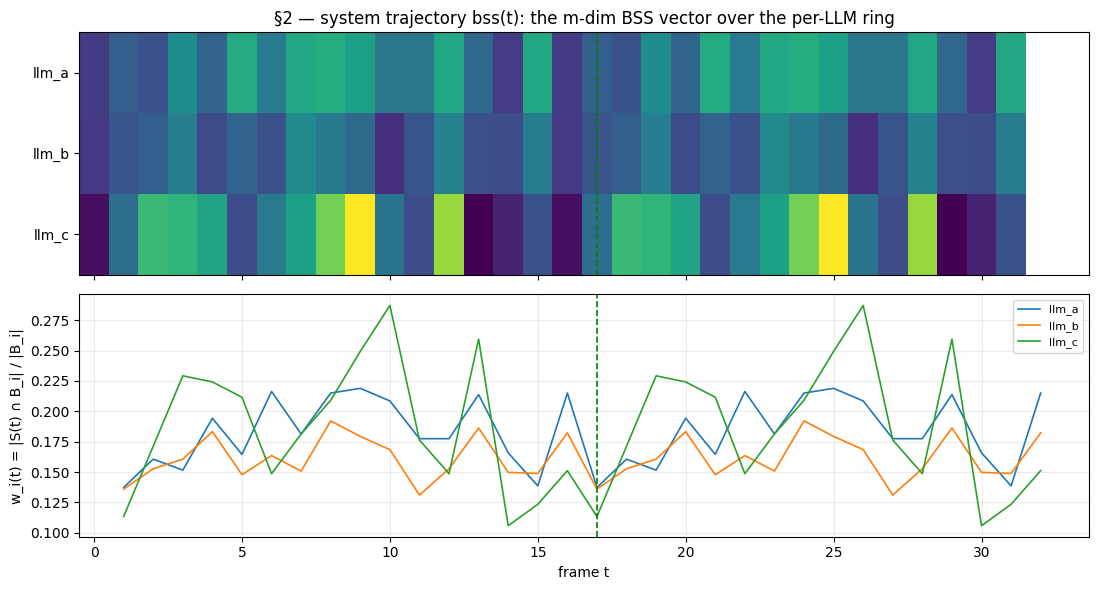

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].imshow(M.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_yticks(range(len(proj["names"])), proj["names"])
axes[0].set_title("§2 — system trajectory bss(t): the m-dim BSS vector over the per-LLM ring")
for n in names:
    i = proj["names"].index(n)
    axes[1].plot(t_axis, M[:, i], label=n, lw=1.2)
axes[1].set_ylabel("w_i(t) = |S(t) ∩ B_i| / |B_i|")
axes[1].set_xlabel("frame t")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
for ax in axes:
    ax.axvline(len(PROMPTS) + 1, color="green", lw=1.2, ls="--")
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_real_bss.png", dpi=110)
plt.show()

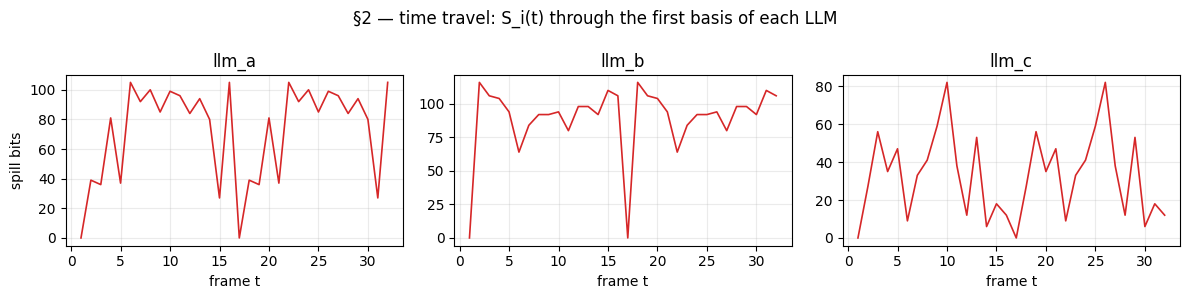

llm_a: final spill through the first basis = 105 bits
llm_b: final spill through the first basis = 106 bits
llm_c: final spill through the first basis = 12 bits


In [10]:
# Time travel (docs/BASIS_FRAMES.md): each S_i(t) re-read through that LLM's
# FIRST basis. spill_first = |S_i(t) \ cover(F_0)| — the mass the initial
# interpretation cannot see.
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
for ax, n in zip(axes, names):
    sc = sidecars[n]
    spill = [f["spill_first"] for f in sc["frames"]]
    ax.plot(t_axis, spill, color="tab:red", lw=1.2)
    ax.set_title(n)
    ax.set_xlabel("frame t")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("spill bits")
fig.suptitle("§2 — time travel: S_i(t) through the first basis of each LLM")
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_real_timetravel.png", dpi=110)
plt.show()

for n in names:
    spill = [f["spill_first"] for f in sidecars[n]["frames"]]
    print(f"{n}: final spill through the first basis = {spill[-1]} bits")

## §3 — (LLM, Ring, DRN): DRN of the union stream and of every S_i(t)

The D/R/N decomposition is stream-agnostic; `ewm-scene noether` computes it
for each real LLM stream, and the pyramid computed it for the union.

In [11]:
noethers = {n: ewm_scene("noether", LLM_JSONL[n]) for n in names}
drn = pyr["drn"]  # system DRN of the union stream

def balance_table(name, dp, rp, np_):
    d = np.array(dp, dtype=float)
    r = np.array(rp, dtype=float)
    n = np.array(np_, dtype=float)
    return {
        "stream": name,
        "ΣD": int(d.sum()), "ΣR": int(r.sum()), "ΣN": int(n.sum()),
        "Σ(|N|-|D|)": int((n - d).sum()),
        "mean(|N|-|D|)": round(float((n - d).mean()), 2),
    }

rows = [balance_table("system S(t)", drn["dp"], drn["rp"], drn["np"])]
for n in names:
    no = noethers[n]
    rows.append(balance_table(n, no["dp"], no["rp"], no["np"]))
for r in rows:
    print(f"{r['stream']:12s} ΣD={r['ΣD']:5d}  ΣR={r['ΣR']:5d}  ΣN={r['ΣN']:5d}  "
          f"Σ(|N|-|D|)={r['Σ(|N|-|D|)']:5d}  mean={r['mean(|N|-|D|)']:6.2f}")

system S(t)  ΣD= 4708  ΣR= 1729  ΣN= 4774  Σ(|N|-|D|)=   66  mean=  2.13
llm_a        ΣD= 2191  ΣR=  443  ΣN= 2255  Σ(|N|-|D|)=   64  mean=  2.06
llm_b        ΣD= 3030  ΣR=  739  ΣN= 3035  Σ(|N|-|D|)=    5  mean=  0.16
llm_c        ΣD= 1018  ΣR=  439  ΣN= 1009  Σ(|N|-|D|)=   -9  mean= -0.29


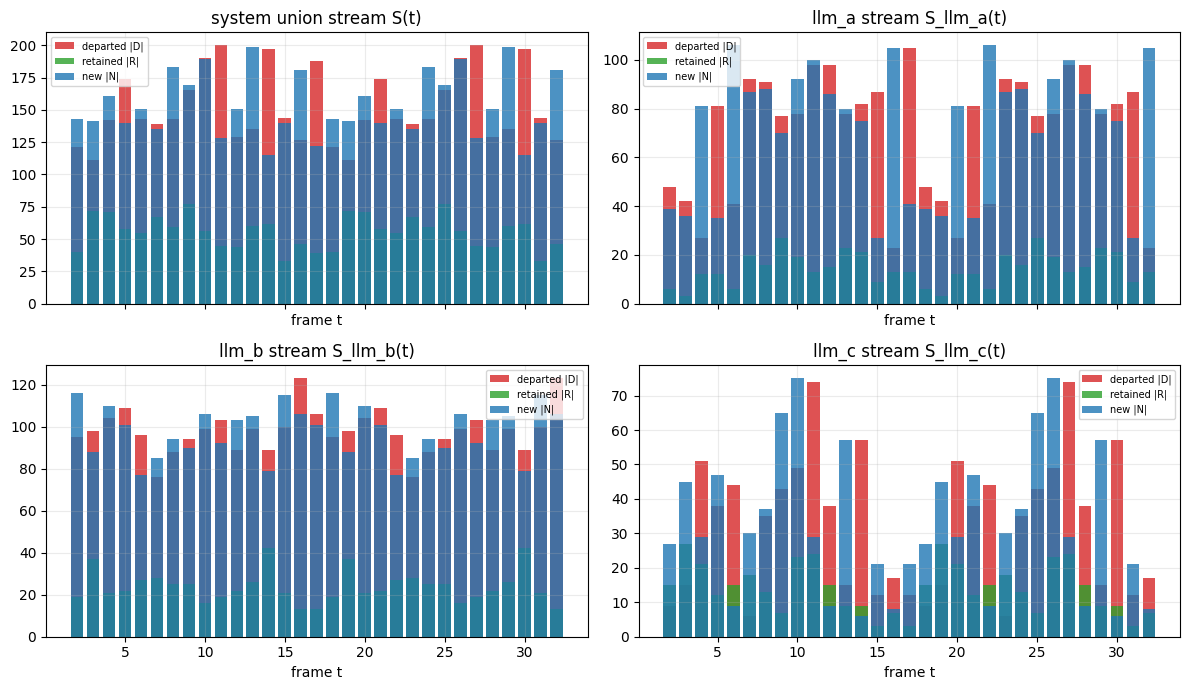

In [12]:
def plot_drn(ax, dp, rp, np_, title):
    dp = np.array(dp, dtype=float)
    rp = np.array(rp, dtype=float)
    np_ = np.array(np_, dtype=float)
    tt = np.arange(2, T + 1)
    ax.bar(tt, dp, color="#d62728", alpha=0.8, label="departed |D|")
    ax.bar(tt, rp, color="#2ca02c", alpha=0.8, label="retained |R|")
    ax.bar(tt, np_, color="#1f77b4", alpha=0.8, label="new |N|")
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
plot_drn(axes[0, 0], drn["dp"], drn["rp"], drn["np"], "system union stream S(t)")
for ax, n in zip(axes.flat[1:], names):
    no = noethers[n]
    plot_drn(ax, no["dp"], no["rp"], no["np"], f"{n} stream S_{n}(t)")
for ax in axes.flat:
    ax.set_xlabel("frame t")
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_real_drn.png", dpi=110)
plt.show()

## §4 — (Ring, Ring, DRN): ring states as virtual LLMs (the recursion step)

`ewm-scene materialize` lowers each real per-LLM HLLSet state back to a
token set; those sets become the leaves of a **second-level pyramid**. The
recursion must discover the same union node, the same DRN and the same ring
— one lattice at every level.

In [13]:
mats = {n: ewm_scene("materialize", LLM_JSONL[n]) for n in names}

RING_PYRAMID_JSONL = f"{WORK}/ring_pyramid_frames.jsonl"
with open(RING_PYRAMID_JSONL, "w") as fh:
    for t in range(T):
        fh.write(json.dumps({"id": t + 1, "perceptrons": {
            f"ring_{n}": mats[n]["frames"][t]["set"] for n in names}}) + "\n")

pyr2 = ewm_scene("pyramid", RING_PYRAMID_JSONL)
print("level-2 perceptrons:", pyr2["names"])

# (1) The second-level union is the same lattice node as the first-level union.
same_union2 = all(pyr2["frames"][i]["union_key"] == pyr["frames"][i]["union_key"] for i in range(T))
print("level-2 union == level-1 union (keys agree):", same_union2)

# (2) The DRN over ring states is identical to the DRN over the original union.
same_drn = (pyr2["drn"]["dp"] == drn["dp"] and pyr2["drn"]["rp"] == drn["rp"]
            and pyr2["drn"]["np"] == drn["np"])
print("level-2 DRN == level-1 DRN:", same_drn)

# (3) Each ring leaf re-ingests to the same per-LLM HLLSet.
pops_ok = True
for t in range(T):
    for n in names:
        p1 = [p for p in pyr["frames"][t]["perceptrons"] if p["name"] == n][0]["pop"]
        p2 = [p for p in pyr2["frames"][t]["perceptrons"] if p["name"] == f"ring_{n}"][0]["pop"]
        pops_ok &= (p1 == p2)
print("ring-leaf pops == per-LLM pops (all frames):", pops_ok)

# (4) The second-level ring over the union stream matches the first-level ring.
ring_ok = all(pyr2["ring"]["frames"][i]["dim"] == pyr["ring"]["frames"][i]["dim"]
              and pyr2["ring"]["frames"][i]["residual"] == pyr["ring"]["frames"][i]["residual"]
              for i in range(T))
print("level-2 ring == level-1 ring (dim + residual):", ring_ok)

level-2 perceptrons: ['ring_llm_a', 'ring_llm_b', 'ring_llm_c']
level-2 union == level-1 union (keys agree): True
level-2 DRN == level-1 DRN: True
ring-leaf pops == per-LLM pops (all frames): True
level-2 ring == level-1 ring (dim + residual): True


## §5 — Training ground: the real-LLM trajectory dataset

The real probes produce the same fixed-shape dataset as notebook 08, plus
one new fact: **the system trajectory is period-16**, because the 16-query
list is replayed with deterministic greedy decoding.

**Target 1 — next BSS vector.** Baselines: persistence (`bss(t)`), linear
extrapolation (`2·bss(t) − bss(t−1)`), cycle replay (ground-truth periodic
baseline), and a 1-NN cycle model trained only on the first cycle and
evaluated on the second.

**Target 2 — next commit signal.** The commit condition
`new bits > 0 or basis changed` is reported; for live LLMs answering
distinct queries every transition commits, and the structural signal is the
**basis plateau** in the second cycle.

In [14]:
# ── Target 1: next BSS vector ─────────────────────────────────────────────
persist_mse = np.mean([np.mean((M[t + 1] - M[t]) ** 2) for t in range(T - 1)])
lin_mse = np.mean([np.mean((M[t + 1] - (2 * M[t] - M[t - 1])) ** 2)
                   for t in range(1, T - 1)])
cycle_mse = np.mean([np.mean((M[t + 1] - M[(t + 1) % len(PROMPTS)]) ** 2)
                     for t in range(len(PROMPTS), T - 1)])

# 1-NN cycle model: prototypes from the first cycle, evaluate on the second.
Xtr = M[:len(PROMPTS)]
Ytr = M[1:len(PROMPTS) + 1]          # Ytr[15] == M[16] == M[0]
Xte = M[len(PROMPTS):T - 1]
Yte = M[len(PROMPTS) + 1:T]
preds = np.array([Ytr[np.argmin(np.linalg.norm(Xtr - x, axis=1))] for x in Xte])
knn_mse = np.mean((preds - Yte) ** 2)

print("target 1 (next BSS vector):")
print(f"  persistence MSE    = {persist_mse:.6f}")
print(f"  linear extrapolation = {lin_mse:.6f}")
print(f"  cycle replay MSE   = {cycle_mse:.6f}   (ground-truth period)")
print(f"  1-NN cycle model   = {knn_mse:.6f}   (learned on first cycle only)")
print("  -> the side-car's bss(t) is periodic; a 1-NN over the first cycle")
print("     generalizes perfectly to the second cycle")

# ── Target 2: next commit signal ──────────────────────────────────────────
dims = [f["dim"] for f in pyr["ring"]["frames"]]
commit = np.zeros(T - 1, dtype=int)
for t in range(T - 1):
    commit[t] = int(drn["np"][t] > 0 or dims[t + 1] != dims[t])
basis_change = np.array([1 if dims[t + 1] != dims[t] else 0 for t in range(T - 1)])

print("\ntarget 2 (next commit signal):")
print(f"  commit rate        = {commit.mean():.3f} ({int(commit.sum())}/{len(commit)} transitions)")
print(f"  basis-change events = {int(basis_change.sum())} of {len(basis_change)} transitions")
print("  -> live LLMs on distinct queries commit every step (new bits > 0);")
print("     the structural signal is the basis plateau: after 16 frames every")
print("     ring stops changing and the trajectory replays in-span")

target 1 (next BSS vector):
  persistence MSE    = 0.002155
  linear extrapolation = 0.005934
  cycle replay MSE   = 0.000000   (ground-truth period)
  1-NN cycle model   = 0.000000   (learned on first cycle only)
  -> the side-car's bss(t) is periodic; a 1-NN over the first cycle
     generalizes perfectly to the second cycle

target 2 (next commit signal):
  commit rate        = 1.000 (31/31 transitions)
  basis-change events = 15 of 31 transitions
  -> live LLMs on distinct queries commit every step (new bits > 0);
     the structural signal is the basis plateau: after 16 frames every
     ring stops changing and the trajectory replays in-span


## Summary

- **Scaffold** — three real small LLMs (DeepSeek 1.5B, Qwen2.5-1.5B-Instruct,
  gpt2) emit `tid{n}` streams into `ewm-scene pyramid`; the union `S(t)` is
  discovered by two paths with one content key (IICA, 32/32).
- **(LLM, Ring)** — each real LLM's Boolean ring saturates at **16
  generations**: the side-car discovers the 16-query cycle from token
  streams alone (`bss(t+16) == bss(t)` exactly, all three dims plateau).
- **(LLM, Ring, DRN)** — the Noether balance table shows the replacement
  budget of each real stream and of the system union.
- **(Ring, Ring, DRN)** — materialized ring states as virtual LLMs reproduce
  the same union node, DRN and ring (recursion closes).
- **Training ground** — persistence and linear extrapolation are beaten by
  the period-aware baselines (cycle replay and 1-NN both 0.0 MSE on the
  second cycle); the commit signal is all-commits for live streams, with the
  basis plateau as the structural event.

Next: keep the same three probes but with **sampled decoding** (non-periodic
streams), and train a sequence model on the trajectory dataset.